<a href="https://colab.research.google.com/github/sandhyacodes2007/Machine_learning/blob/main/adaboost_demoipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [21]:
df= pd.DataFrame({
    'X1':[1,2,3,4,5,6,6,7,9,9],
    'X2':[5,3,6,8,1,9,5,8,9,2],
    'label':[1,1,0,1,0,1,0,1,0,0]
})

In [22]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


AttributeError: PathCollection.set() got an unexpected keyword argument 'X'

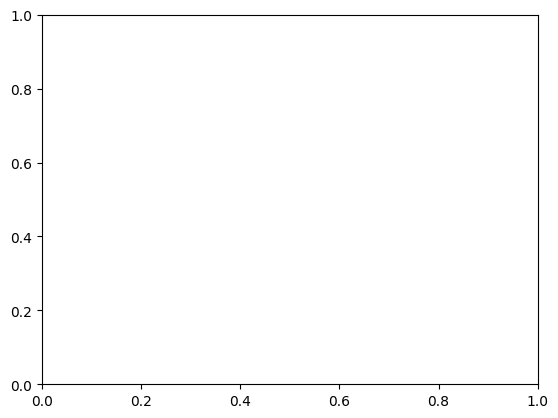

In [23]:

import seaborn as sns
sns.scatterplot(X=df['X1'],y= df['X2'],hue=df['label'])

<Axes: xlabel='X1', ylabel='X2'>

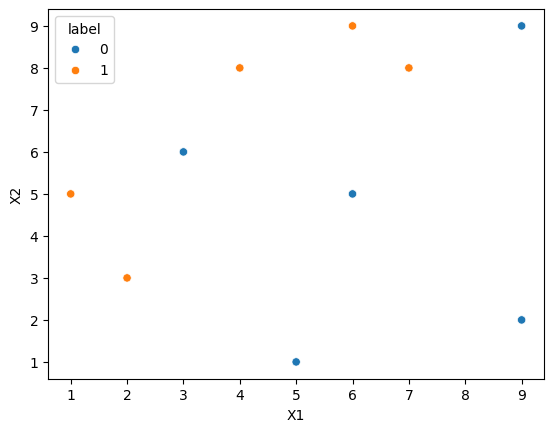

In [24]:
sns.scatterplot(x=df['X1'], y=df['X2'], hue=df['label'])

In [25]:
df['weights']=1/df.shape[0]

In [26]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [27]:
from sklearn.tree import DecisionTreeClassifier

In [28]:
dt1=DecisionTreeClassifier(max_depth=1)

In [29]:
X=df.iloc[:,0:2].values
y=df.iloc[:,2].values

In [30]:
#step 2 -Train 1st model
dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

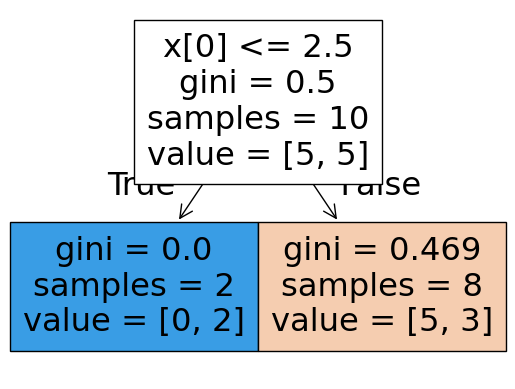

In [31]:

from sklearn.tree import plot_tree
plot_tree(dt1,filled=True)

<Axes: >

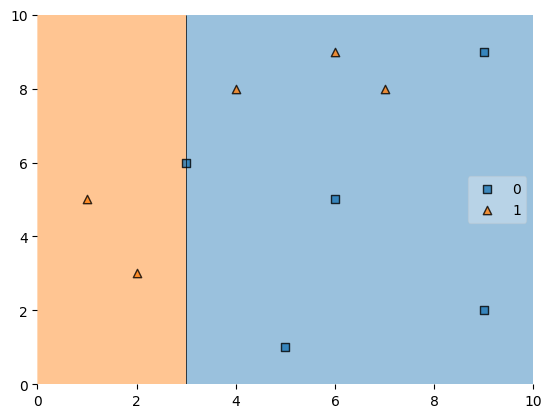

In [32]:
plot_decision_regions(X,y,clf=dt1,legend=5)

In [33]:
df['y_pred']=dt1.predict(X)

In [34]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [65]:
def calculate_model_weight(error):

  return 0.5*np.log((1-error)/(error+0.000001))

In [66]:
#step 3 - calculate model weight
alpha1= calculate_model_weight(0.3)
alpha1

np.float64(0.42364726352971294)

In [67]:
#step 4 - update weights
def update_row_weights(row, alpha=0.423):
  if row['label']==row['y_pred']:
    return row['weights']*np.exp(-alpha)
  else:
    return row['weights']*np.exp(alpha)

In [68]:
df['updated_weights']= df.apply(update_row_weights, axis=1)

In [69]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,0,0.065508,0.071475,0.214425,0.142950
3,4,8,1,0.1,0,0.152653,0.166559,0.380983,0.214425
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,0,0.152653,0.166559,0.619017,0.452458
6,6,5,0,0.1,0,0.065508,0.071475,0.690492,0.619017
7,7,8,1,0.1,0,0.152653,0.166559,0.857050,0.690492
8,9,9,0,0.1,0,0.065508,0.071475,0.928525,0.857050
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [70]:
df['updated_weights'].sum()

np.float64(0.9165153319682015)

In [71]:
df['normalized_weights']= df['updated_weights']/df['updated_weights'].sum()

In [72]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,0,0.065508,0.071475,0.214425,0.142950
3,4,8,1,0.1,0,0.152653,0.166559,0.380983,0.214425
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,0,0.152653,0.166559,0.619017,0.452458
6,6,5,0,0.1,0,0.065508,0.071475,0.690492,0.619017
7,7,8,1,0.1,0,0.152653,0.166559,0.857050,0.690492
8,9,9,0,0.1,0,0.065508,0.071475,0.928525,0.857050
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [73]:
df['normalized_weights'].sum()

np.float64(1.0)

In [74]:
df['cumsum_upper']= np.cumsum(df['normalized_weights'])

In [75]:
df['cumsum_lower']=df['cumsum_upper']-df['normalized_weights']

In [76]:
df[['X1','X2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,0,0.065508,0.142950,0.214425
3,4,8,1,0.1,0,0.152653,0.214425,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,0,0.152653,0.452458,0.619017
6,6,5,0,0.1,0,0.065508,0.619017,0.690492
7,7,8,1,0.1,0,0.152653,0.690492,0.857050
8,9,9,0,0.1,0,0.065508,0.857050,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [77]:
def create_new_dataset(df):
  indices=[]

  for i in range(df.shape[0]):
    a= np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper']>a and a>row['cumsum_lower']:
        indices.append(index)
  return indices

In [78]:
index_values= create_new_dataset(df)

In [79]:
index_values

[0, 6, 9, 6, 2, 3, 9, 0, 1, 3]

In [80]:
second_df= df.iloc[index_values,[0,1,2,3]]

In [81]:
second_df

,X1,X2,label,weights
0,1,5,1,0.1
6,6,5,0,0.1
9,9,2,0,0.1
6,6,5,0,0.1
2,3,6,0,0.1
3,4,8,1,0.1
9,9,2,0,0.1
0,1,5,1,0.1
1,2,3,1,0.1
3,4,8,1,0.1


In [82]:
dt2= DecisionTreeClassifier(max_depth=1)

In [83]:
X= second_df.iloc[:,0:2].values
y= second_df.iloc[:,2].values

In [84]:
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 5.0\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.278\nsamples = 6\nvalue = [1, 5]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.625, 0.5, '  False')]

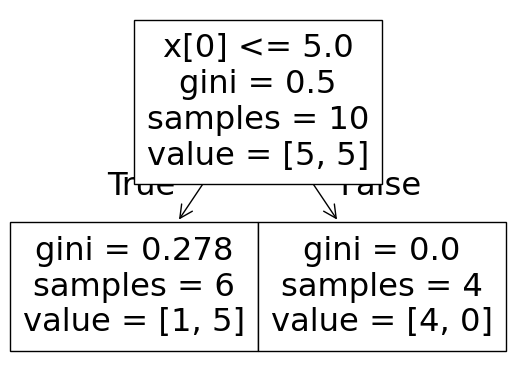

In [85]:
plot_tree(dt2)

<Axes: >

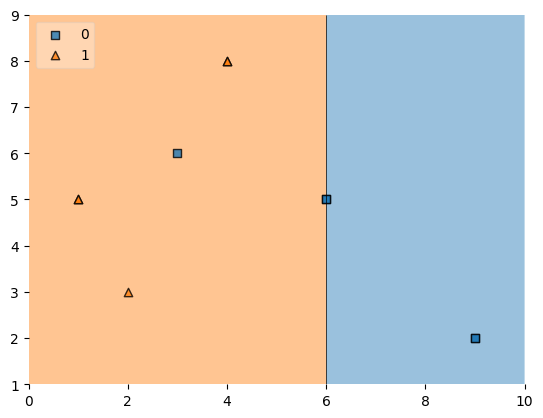

In [86]:
plot_decision_regions(X,y,clf=dt2,legend=2)

In [87]:
second_df['y_pred']= dt2.predict(X)

In [88]:
second_df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
6,6,5,0,0.1,0
9,9,2,0,0.1,0
6,6,5,0,0.1,0
2,3,6,0,0.1,1
3,4,8,1,0.1,1
9,9,2,0,0.1,0
0,1,5,1,0.1,1
1,2,3,1,0.1,1
3,4,8,1,0.1,1


In [89]:
alpha2= calculate_model_weight(0.1)

In [90]:
alpha2

np.float64(1.0986072886931095)

In [91]:
def update_row_weights(row,alpha=1.09):
  if row['label']==row['y_pred']:
    return row['weights']*np.exp(-alpha)
  else:
    return row['weights']*np.exp(alpha)

In [94]:
second_df['update_weights']= second_df.apply(update_row_weights,axis=1)
second_df['normalized_weights']=second_df['update_weights']/second_df['update_weights'].sum()

In [95]:
second_df

,X1,X2,label,weights,y_pred,update_weights,normalized_weights
0,1,5,1,0.1,1,0.033622,0.056034
6,6,5,0,0.1,0,0.033622,0.056034
9,9,2,0,0.1,0,0.033622,0.056034
6,6,5,0,0.1,0,0.033622,0.056034
2,3,6,0,0.1,1,0.297427,0.495694
3,4,8,1,0.1,1,0.033622,0.056034
9,9,2,0,0.1,0,0.033622,0.056034
0,1,5,1,0.1,1,0.033622,0.056034
1,2,3,1,0.1,1,0.033622,0.056034
3,4,8,1,0.1,1,0.033622,0.056034


In [96]:
second_df['normalized_weights'].sum()

np.float64(0.9999999999999999)

In [97]:
second_df['cumsum_upper']= np.cumsum(second_df['normalized_weights'])

In [98]:
second_df['cumsum_lower']= second_df['cumsum_upper']-second_df['normalized_weights']

In [102]:
second_df[['X1','X2','label','weights','y_pred','normalized_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,normalized_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.056034,0.000000,0.056034
6,6,5,0,0.1,0,0.056034,0.056034,0.112068
9,9,2,0,0.1,0,0.056034,0.112068,0.168102
6,6,5,0,0.1,0,0.056034,0.168102,0.224136
2,3,6,0,0.1,1,0.495694,0.224136,0.719830
3,4,8,1,0.1,1,0.056034,0.719830,0.775864
9,9,2,0,0.1,0,0.056034,0.775864,0.831898
0,1,5,1,0.1,1,0.056034,0.831898,0.887932
1,2,3,1,0.1,1,0.056034,0.887932,0.943966
3,4,8,1,0.1,1,0.056034,0.943966,1.000000


In [103]:
index_val= create_new_dataset(second_df)

In [104]:
third_df= second_df.iloc[index_val, [0,1,2,3]]

In [105]:
third_df

,X1,X2,label,weights
3,4,8,1,0.1
9,9,2,0,0.1
6,6,5,0,0.1
9,9,2,0,0.1
6,6,5,0,0.1
6,6,5,0,0.1
9,9,2,0,0.1
3,4,8,1,0.1
3,4,8,1,0.1
9,9,2,0,0.1


In [106]:
dt3= DecisionTreeClassifier(max_depth=1)
X= second_df.iloc[:,0:2].values
y= second_df.iloc[:,2].values

In [107]:
dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

<Axes: >

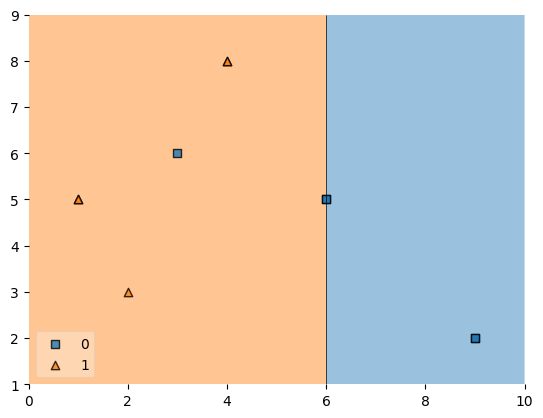

In [108]:
plot_decision_regions(X,y,clf=dt3,legend=3)

[Text(0.5, 0.75, 'x[0] <= 5.0\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.278\nsamples = 6\nvalue = [1, 5]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.625, 0.5, '  False')]

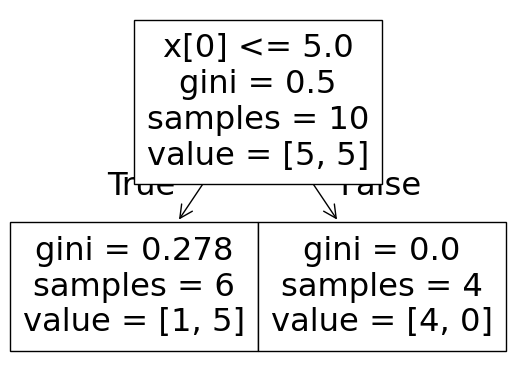

In [109]:
plot_tree(dt3)

In [110]:
alpha3= calculate_model_weight(0.7)

In [111]:
alpha3

np.float64(-0.42364964447880576)

In [112]:
print(alpha1,alpha2,alpha3)

0.42364726352971294 1.0986072886931095 -0.42364964447880576


In [113]:
query= np.array([1,5]).reshape(1,2)

In [114]:
dt2.predict(query)

array([1])

In [115]:
dt3.predict(query)

array([1])

In [117]:
alpha1*1 + alpha2*(-1) +alpha3*(-1)

np.float64(-0.25131038068459083)

In [123]:
np.sign(-0.2513)

np.float64(-1.0)

In [124]:
query= np.array([9,9]).reshape(1,2)
dt1.predict(query)

array([0])

In [125]:
dt2.predict(query)

array([0])

In [126]:
dt3.predict(query)

array([0])